In [16]:
# bibliotecas
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D 
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [22]:
df = pd.read_csv("wow_text.csv")

In [26]:
# lê o CSV com para evitar erro de caracteres (coloquei erros la)
df = pd.read_csv("wow_text.csv")
# mostra as 5 primeiras linhas do dataframe
df.head()
# tirando as colunas que não precisa
# df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1) Não precisa o meu é autoral e limpo  

,label,text
0,positivo,finalmente dropei a mount rara slk bom dms
1,negativo,wipe no primeiro boss q odio mano
2,positivo,monk ww ta mt forte no pvp
3,negativo,40 min fila arena pra nada aff
4,positivo,peguei gear top na mythic+ hj


In [29]:
# renomeando colunas dnv
df.columns = ['Positivo/negativo', 'dados']
df.head()

,Positivo/negativo,dados
0,positivo,finalmente dropei a mount rara slk bom dms
1,negativo,wipe no primeiro boss q odio mano
2,positivo,monk ww ta mt forte no pvp
3,negativo,40 min fila arena pra nada aff
4,positivo,peguei gear top na mythic+ hj


In [32]:
# mapeando
df['target'] = df['Positivo/negativo'].map({'positivo': 1, 'negativo': 0})
Y = df['target'].values

In [33]:
# split de treino e teste
df_train, df_test, Ytrain, Ytest = train_test_split(df['dados'], Y, test_size=0.33)

In [38]:
# Pr3-processamento Tokenização e Padding
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)

sequencias_train = tokenizer.texts_to_sequences(df_train)
sequencias_test = tokenizer.texts_to_sequences(df_test)

In [41]:
T = 15 # Definindo o tamanho máximo 
Xtrain = pad_sequences(sequencias_train, maxlen=T)
Xtest = pad_sequences(sequencias_test, maxlen=T)
V = len(tokenizer.word_index)

In [42]:
# criando a Arquitetura CNN (Igual à aula)
D = 20 # Dimensão do embedding

i = Input(shape=(T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

2026-03-03 13:36:12.303722: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [44]:
# compilação e Treino
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [45]:
r = model.fit(
    Xtrain, Ytrain, 
    epochs=20, 
    validation_data=(Xtest, Ytest)
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8000 - loss: 0.6888 - val_accuracy: 0.3333 - val_loss: 0.6951
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8000 - loss: 0.6834 - val_accuracy: 0.3333 - val_loss: 0.6966
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8000 - loss: 0.6782 - val_accuracy: 0.3333 - val_loss: 0.6982
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8000 - loss: 0.6734 - val_accuracy: 0.3333 - val_loss: 0.6997
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8000 - loss: 0.6686 - val_accuracy: 0.3333 - val_loss: 0.7012
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8000 - loss: 0.6637 - val_accuracy: 0.3333 - val_loss: 0.7027
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6000 - loss: 0.6588 - val_accuracy: 0.3333 - val_loss: 0.7043
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6540 - val_accuracy: 0.3333 - val_loss: 0.7058
Ep

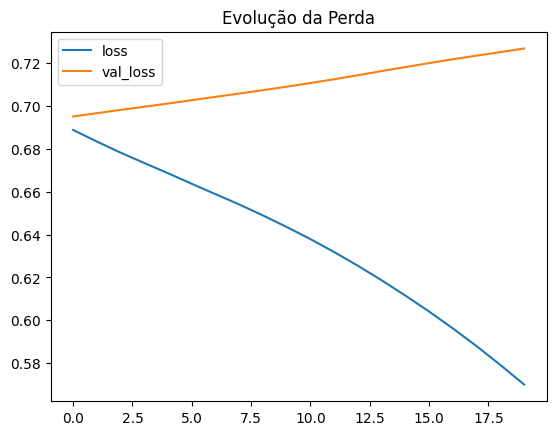

In [47]:
# visualização dos Resultados
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.title("Evolução da Perda")
plt.legend()
plt.show()